# Seeded Pair Statistical Tests — 4-Class Task

Performs paired statistical tests comparing **homogeneous anchor** vs **heterogeneous sampled** SNN accuracy across seeded pairs.

Tests performed:
1. **Paired t-test** — parametric, assumes normality of differences
2. **Wilcoxon signed-rank test** — non-parametric, no distributional assumptions

Also loads 2-class seeded results for cross-task comparison, and compares to the heterogeneity improvement reported in **Perez-Nieves et al. (2021)** on the SHD task.

In [1]:
import sys
sys.path.insert(0, r"C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files")

from pathlib import Path
import importlib

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import seeded_runs_common as seeded_runs_common
seeded_runs_common = importlib.reload(seeded_runs_common)

CHECKPOINT_ROOT = seeded_runs_common.CHECKPOINT_ROOT
read_manifest_rows = seeded_runs_common.read_manifest_rows

sns.set_theme(style="whitegrid", context="notebook", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded.")
print(f"Checkpoint root: {CHECKPOINT_ROOT}")

Libraries loaded.
Checkpoint root: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Checkpoints\SeededRuns


## 1. Load All Seeded Run Results

Load checkpoint summaries from:
- **Seeded Run 1 — 4-class** (this notebook's run)
- **Seeded Run 1 — 2-class** (for cross-task reference)
- **Seeded Run 2 — 2-class** (additional 2-class data)

In [8]:
def load_paired_acc_df(run_label, task_key, mem_family="lognormal"):
    """Load checkpoint rows and pivot into paired accuracy DataFrame."""
    stem = CHECKPOINT_ROOT / run_label / f"{task_key}_{mem_family}" / f"{run_label}_checkpoint_summary"
    rows = read_manifest_rows(stem)

    if not rows:
        print(f"  ⚠ No checkpoint data for {run_label} / {task_key}")
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    paired = df.pivot(
        index="pair_seed", columns="pair_role", values="final_test_acc"
    ).reset_index()
    paired.columns.name = None

    if "heterogeneous_sampled" in paired.columns and "homogeneous_anchor" in paired.columns:
        paired["hetero_minus_hom"] = (
            paired["heterogeneous_sampled"] - paired["homogeneous_anchor"]
        )
        paired["run_label"] = run_label
        paired["task_key"] = task_key
        paired["n_pairs"] = len(paired)
    return paired

# Load all available results
results_4c = load_paired_acc_df("seeded_run_1", "4class")
results_2c_r1 = load_paired_acc_df("seeded_run_1", "2class")
results_2c_r2 = load_paired_acc_df("seeded_run_2", "2class")

# Combine 2-class runs
all_2c = pd.concat([results_2c_r1, results_2c_r2], ignore_index=True) if not results_2c_r1.empty else results_2c_r2

print("\n=== 4-Class Results ===")
if not results_4c.empty:
    display(results_4c[["pair_seed", "heterogeneous_sampled", "homogeneous_anchor", "hetero_minus_hom"]])
else:
    print("  No results yet.")

print("\n=== 2-Class Results (combined runs 1+2) ===")
if not all_2c.empty:
    display(all_2c[["run_label", "pair_seed", "heterogeneous_sampled", "homogeneous_anchor", "hetero_minus_hom"]])
else:
    print("  No results yet.")


=== 4-Class Results ===


,pair_seed,heterogeneous_sampled,homogeneous_anchor,hetero_minus_hom
0,101,0.494700,0.626325,-0.131625
1,202,0.564488,0.598940,-0.034452
2,210,0.564046,0.546378,0.017668
3,340,0.562721,0.534452,0.028269
4,440,0.451855,0.587456,-0.135601



=== 2-Class Results (combined runs 1+2) ===


,run_label,pair_seed,heterogeneous_sampled,homogeneous_anchor,hetero_minus_hom
0,seeded_run_1,101,0.824205,0.826855,-0.002650
1,seeded_run_1,202,0.845406,0.779594,0.065813
2,seeded_run_1,210,0.801237,0.730565,0.070671
3,seeded_run_1,340,0.791519,0.753092,0.038428
4,seeded_run_1,440,0.810512,0.848498,-0.037986
5,seeded_run_2,201,0.864841,0.844965,0.019876
6,seeded_run_2,211,0.506184,0.758834,-0.252650
7,seeded_run_2,221,0.822880,0.809187,0.013693
8,seeded_run_2,231,0.762367,0.733657,0.028710
9,seeded_run_2,241,0.827297,0.758834,0.068463


## 2. Paired T-Test

**H₀:** μ_hetero − μ_homo = 0 (no difference in mean accuracy)  
**H₁:** μ_hetero − μ_homo > 0 (heterogeneous outperforms homogeneous)

One-sided test since the hypothesis is directional — heterogeneity should help.

In [9]:
def run_paired_ttest(paired_df, task_label, alpha=0.05):
    """Run one-sided paired t-test on hetero - homo accuracy differences."""
    diffs = paired_df["hetero_minus_hom"].values
    n = len(diffs)

    if n < 2:
        print(f"  ⚠ {task_label}: only {n} pair(s) — cannot run t-test (need ≥ 2)")
        return None

    t_stat, p_two_sided = stats.ttest_rel(
        paired_df["heterogeneous_sampled"],
        paired_df["homogeneous_anchor"],
        alternative="greater",  # one-sided: hetero > homo
    )

    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs, ddof=1)
    cohens_d = mean_diff / sd_diff if sd_diff > 0 else 0.0
    ci_95 = stats.t.interval(0.95, df=n-1, loc=mean_diff, scale=sd_diff / np.sqrt(n))

    result = {
        "task": task_label,
        "n_pairs": n,
        "mean_diff": mean_diff,
        "sd_diff": sd_diff,
        "t_statistic": t_stat,
        "p_value": p_two_sided,  # already one-sided from alternative='greater'
        "significant": p_two_sided < alpha,
        "cohens_d": cohens_d,
        "ci_95_lower": ci_95[0],
        "ci_95_upper": ci_95[1],
    }

    print(f"\n{'='*60}")
    print(f"  Paired t-test: {task_label}")
    print(f"{'='*60}")
    print(f"  Pairs (n):           {n}")
    print(f"  Mean diff (Δacc):    {mean_diff:+.4f}  ({mean_diff*100:+.2f} pp)")
    print(f"  SD of differences:   {sd_diff:.4f}")
    print(f"  t-statistic:         {t_stat:.4f}")
    print(f"  p-value (1-sided):   {p_two_sided:.6f}")
    print(f"  Significant @ α=0.05: {p_two_sided < alpha}")
    print(f"  Cohen's d:           {cohens_d:.4f}")
    print(f"  95% CI for Δacc:     [{ci_95[0]:+.4f}, {ci_95[1]:+.4f}]")

    if p_two_sided < 0.001:
        print(f"  ★★★ Highly significant (p < 0.001)")
    elif p_two_sided < 0.01:
        print(f"  ★★  Very significant (p < 0.01)")
    elif p_two_sided < 0.05:
        print(f"  ★   Significant (p < 0.05)")
    else:
        print(f"  —   Not significant")

    return result

t_results = {}

# 4-class test
if not results_4c.empty:
    t_results["4-class"] = run_paired_ttest(results_4c, "4-Class Parity×Language")

# 2-class test (combined runs)
if not all_2c.empty:
    t_results["2-class"] = run_paired_ttest(all_2c, "2-Class Parity (runs 1+2)")

# 2-class per-run
if not results_2c_r1.empty:
    t_results["2-class (run 1)"] = run_paired_ttest(results_2c_r1, "2-Class Parity (run 1 only)")
if not results_2c_r2.empty:
    t_results["2-class (run 2)"] = run_paired_ttest(results_2c_r2, "2-Class Parity (run 2 only)")


  Paired t-test: 4-Class Parity×Language
  Pairs (n):           5
  Mean diff (Δacc):    -0.0511  (-5.11 pp)
  SD of differences:   0.0789
  t-statistic:         -1.4487
  p-value (1-sided):   0.889501
  Significant @ α=0.05: False
  Cohen's d:           -0.6479
  95% CI for Δacc:     [-0.1492, +0.0469]
  —   Not significant

  Paired t-test: 2-Class Parity (runs 1+2)
  Pairs (n):           10
  Mean diff (Δacc):    +0.0012  (+0.12 pp)
  SD of differences:   0.0955
  t-statistic:         0.0409
  p-value (1-sided):   0.484122
  Significant @ α=0.05: False
  Cohen's d:           0.0129
  95% CI for Δacc:     [-0.0671, +0.0696]
  —   Not significant

  Paired t-test: 2-Class Parity (run 1 only)
  Pairs (n):           5
  Mean diff (Δacc):    +0.0269  (+2.69 pp)
  SD of differences:   0.0465
  t-statistic:         1.2916
  p-value (1-sided):   0.133039
  Significant @ α=0.05: False
  Cohen's d:           0.5776
  95% CI for Δacc:     [-0.0309, +0.0846]
  —   Not significant

  Paired t-t

## 3. Wilcoxon Signed-Rank Test

**Non-parametric** alternative to the paired t-test. Does not assume normality of differences.

**H₀:** Median difference = 0  
**H₁:** Median difference > 0 (hetero outperforms homo)

In [10]:
def run_wilcoxon(paired_df, task_label, alpha=0.05):
    """Run one-sided Wilcoxon signed-rank test."""
    diffs = paired_df["hetero_minus_hom"].values
    n = len(diffs)

    if n < 3:
        print(f"  ⚠ {task_label}: only {n} pair(s) — Wilcoxon requires ≥ 3 for meaningful results")
        return None

    # Wilcoxon signed-rank test (one-sided: hetero > homo)
    w_stat, p_two_sided = stats.wilcoxon(
        paired_df["heterogeneous_sampled"],
        paired_df["homogeneous_anchor"],
        alternative="greater",
    )

    # Count positive vs negative differences
    n_pos = int(np.sum(diffs > 0))
    n_neg = int(np.sum(diffs < 0))
    n_tie = int(np.sum(np.isclose(diffs, 0)))
    median_diff = np.median(diffs)

    result = {
        "task": task_label,
        "n_pairs": n,
        "median_diff": median_diff,
        "n_positive": n_pos,
        "n_negative": n_neg,
        "n_ties": n_tie,
        "W_statistic": w_stat,
        "p_value": p_two_sided,
        "significant": p_two_sided < alpha,
    }

    print(f"\n{'='*60}")
    print(f"  Wilcoxon Signed-Rank Test: {task_label}")
    print(f"{'='*60}")
    print(f"  Pairs (n):                {n}")
    print(f"  Median diff (Δacc):       {median_diff:+.4f}  ({median_diff*100:+.2f} pp)")
    print(f"  Positive Δ (hetero > hom): {n_pos}")
    print(f"  Negative Δ (hom > hetero): {n_neg}")
    print(f"  Ties:                     {n_tie}")
    print(f"  W-statistic:              {w_stat:.1f}")
    print(f"  p-value (1-sided):        {p_two_sided:.6f}")
    print(f"  Significant @ α=0.05:     {p_two_sided < alpha}")

    if p_two_sided < 0.01:
        print(f"  ★★  Very significant (p < 0.01)")
    elif p_two_sided < 0.05:
        print(f"  ★   Significant (p < 0.05)")
    else:
        print(f"  —   Not significant")

    return result

w_results = {}

if not results_4c.empty:
    w_results["4-class"] = run_wilcoxon(results_4c, "4-Class Parity×Language")

if not all_2c.empty:
    w_results["2-class"] = run_wilcoxon(all_2c, "2-Class Parity (runs 1+2)")

if not results_2c_r1.empty:
    w_results["2-class (run 1)"] = run_wilcoxon(results_2c_r1, "2-Class Parity (run 1 only)")
if not results_2c_r2.empty:
    w_results["2-class (run 2)"] = run_wilcoxon(results_2c_r2, "2-Class Parity (run 2 only)")


  Wilcoxon Signed-Rank Test: 4-Class Parity×Language
  Pairs (n):                5
  Median diff (Δacc):       -0.0345  (-3.45 pp)
  Positive Δ (hetero > hom): 2
  Negative Δ (hom > hetero): 3
  Ties:                     0
  W-statistic:              3.0
  p-value (1-sided):        0.906250
  Significant @ α=0.05:     False
  —   Not significant

  Wilcoxon Signed-Rank Test: 2-Class Parity (runs 1+2)
  Pairs (n):                10
  Median diff (Δacc):       +0.0243  (+2.43 pp)
  Positive Δ (hetero > hom): 7
  Negative Δ (hom > hetero): 3
  Ties:                     0
  W-statistic:              39.0
  p-value (1-sided):        0.137695
  Significant @ α=0.05:     False
  —   Not significant

  Wilcoxon Signed-Rank Test: 2-Class Parity (run 1 only)
  Pairs (n):                5
  Median diff (Δacc):       +0.0384  (+3.84 pp)
  Positive Δ (hetero > hom): 3
  Negative Δ (hom > hetero): 2
  Ties:                     0
  W-statistic:              12.0
  p-value (1-sided):        0.156250


## 4. Comparison to Perez-Nieves et al. (2021)

**Reference:** Perez-Nieves et al. (2021) "Neural heterogeneity promotes robust learning." *Nature Communications*, 12, 5791.

The paper reports that adding membrane time constant (τ_m) heterogeneity to SNNs improves SHD classification accuracy. Key context:

| Aspect | Perez-Nieves Paper | This Study |
|--------|-------------------|------------|
| Hidden neurons | 128 | 32 |
| Epochs | 150 | 25 |
| Time step | 0.5 ms | 1.0 ms |
| Heterogeneity type | Learned per-neuron τ | Sampled log-normal τ, frozen |
| Task | 20-class SHD | 2-class / 4-class parity×language |

The paper's core finding was that heterogeneous τ_m networks reliably outperform homogeneous ones, with improvements on the order of **~3–5 percentage points** for the full SHD 20-class task, and that this gap widens under noise/distortion conditions.

Below we compare our observed heterogeneity advantage against this benchmark.

In [11]:
# Perez-Nieves reference benchmark
# The paper reports heterogeneity improving SHD accuracy by ~3-8 pp depending on condition
# (exact numbers vary by figure; the canonical result is ~5 pp on clean SHD with 128 neurons)
PEREZ_NIEVES_IMPROVEMENT_PP = 5.0  # approximate central estimate in percentage points
PEREZ_NIEVES_RANGE_PP = (3.0, 8.0)  # reported range across conditions

print("=" * 70)
print("  Comparison: Observed Heterogeneity Advantage vs Perez-Nieves (2021)")
print("=" * 70)
print(f"  Perez-Nieves benchmark improvement on SHD: ~{PEREZ_NIEVES_IMPROVEMENT_PP:.1f} pp")
print(f"  Reported range across conditions:          [{PEREZ_NIEVES_RANGE_PP[0]:.1f}, {PEREZ_NIEVES_RANGE_PP[1]:.1f}] pp")
print()

for label, t_res in t_results.items():
    if t_res is None:
        continue
    obs_pp = t_res["mean_diff"] * 100
    in_range = PEREZ_NIEVES_RANGE_PP[0] <= obs_pp <= PEREZ_NIEVES_RANGE_PP[1]
    above = obs_pp > PEREZ_NIEVES_RANGE_PP[1]

    print(f"  {label}:")
    print(f"    Observed Δacc:    {obs_pp:+.2f} pp")
    print(f"    vs Perez-Nieves:  ", end="")
    if above:
        print(f"ABOVE benchmark range (> {PEREZ_NIEVES_RANGE_PP[1]:.1f} pp) ✓")
    elif in_range:
        print(f"WITHIN benchmark range [{PEREZ_NIEVES_RANGE_PP[0]:.1f}–{PEREZ_NIEVES_RANGE_PP[1]:.1f} pp] ✓")
    else:
        print(f"below benchmark range (< {PEREZ_NIEVES_RANGE_PP[0]:.1f} pp)")
    print(f"    Cohen's d:        {t_res['cohens_d']:.3f}")
    print(f"    Significant:      {t_res['significant']}")
    print()

  Comparison: Observed Heterogeneity Advantage vs Perez-Nieves (2021)
  Perez-Nieves benchmark improvement on SHD: ~5.0 pp
  Reported range across conditions:          [3.0, 8.0] pp

  4-class:
    Observed Δacc:    -5.11 pp
    vs Perez-Nieves:  below benchmark range (< 3.0 pp)
    Cohen's d:        -0.648
    Significant:      False

  2-class:
    Observed Δacc:    +0.12 pp
    vs Perez-Nieves:  below benchmark range (< 3.0 pp)
    Cohen's d:        0.013
    Significant:      False

  2-class (run 1):
    Observed Δacc:    +2.69 pp
    vs Perez-Nieves:  below benchmark range (< 3.0 pp)
    Cohen's d:        0.578
    Significant:      False

  2-class (run 2):
    Observed Δacc:    -2.44 pp
    vs Perez-Nieves:  below benchmark range (< 3.0 pp)
    Cohen's d:        -0.188
    Significant:      False



## 5. Visualization: Paired Accuracy Differences

C:\Users\Priya\AppData\Local\Temp\ipykernel_41920\2831782729.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Task", y="Δ Accuracy (pp)", palette=colors,


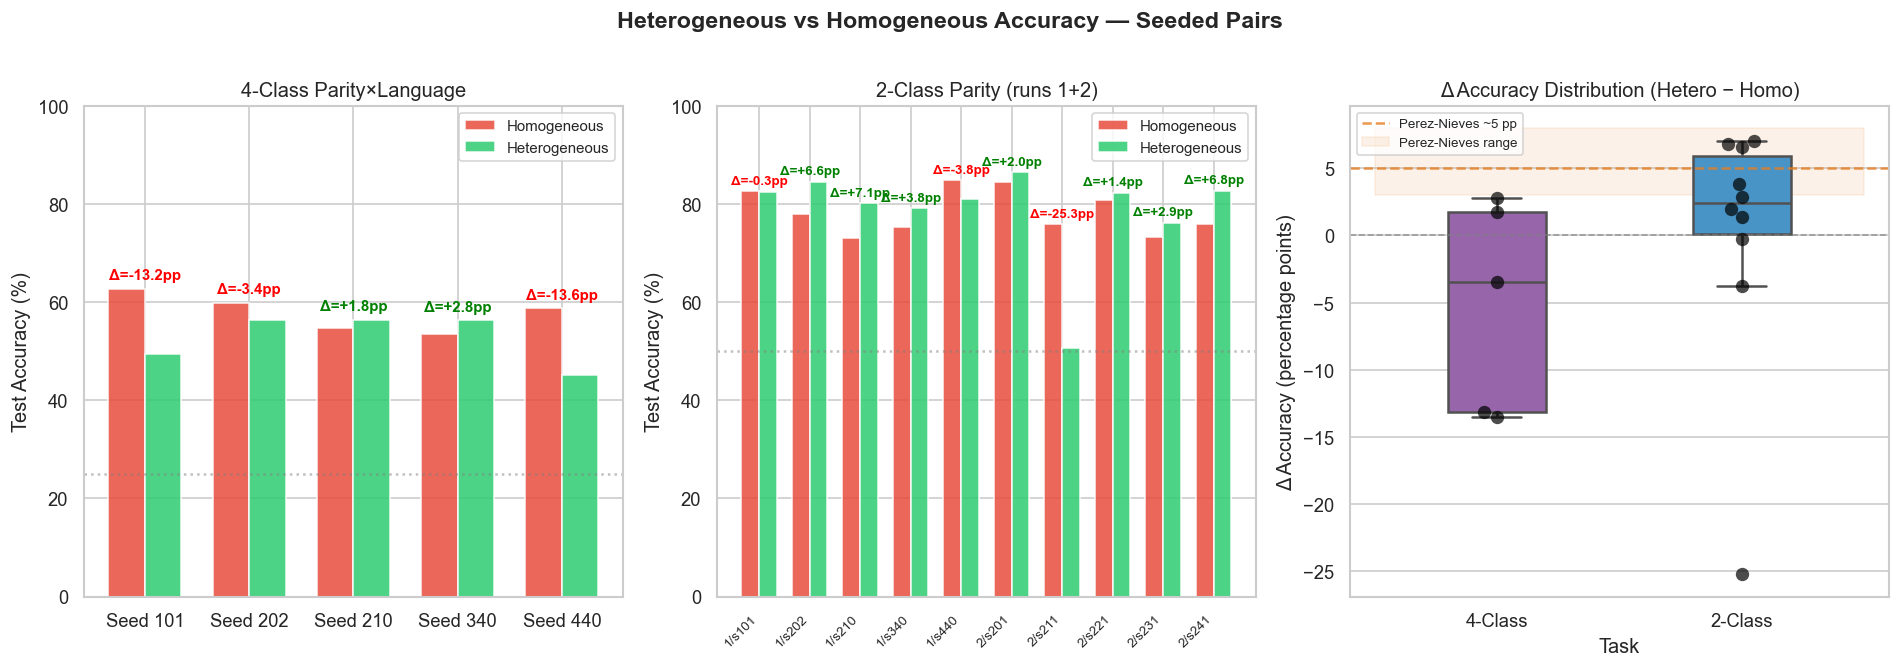

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle("Heterogeneous vs Homogeneous Accuracy — Seeded Pairs", fontsize=14, fontweight="bold", y=1.01)

# --- Panel 1: 4-class paired bar chart ---
ax = axes[0]
if not results_4c.empty:
    x = np.arange(len(results_4c))
    width = 0.35
    bars1 = ax.bar(x - width/2, results_4c["homogeneous_anchor"] * 100, width,
                   label="Homogeneous", color="#E74C3C", alpha=0.85, edgecolor="white")
    bars2 = ax.bar(x + width/2, results_4c["heterogeneous_sampled"] * 100, width,
                   label="Heterogeneous", color="#2ECC71", alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"Seed {int(s)}" for s in results_4c["pair_seed"]])
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("4-Class Parity×Language")
    ax.legend(fontsize=9)
    ax.axhline(y=25, color="gray", linestyle=":", alpha=0.5, label="Chance (25%)")
    ax.set_ylim(0, 100)

    # Annotate differences
    for i, row in results_4c.iterrows():
        diff = row["hetero_minus_hom"] * 100
        y_max = max(row["heterogeneous_sampled"], row["homogeneous_anchor"]) * 100
        ax.annotate(f"Δ={diff:+.1f}pp", (i, y_max + 2), ha="center", fontsize=9,
                    fontweight="bold", color="green" if diff > 0 else "red")
else:
    ax.text(0.5, 0.5, "No 4-class data yet", transform=ax.transAxes, ha="center", va="center")
    ax.set_title("4-Class (pending)")

# --- Panel 2: 2-class paired bar chart ---
ax = axes[1]
if not all_2c.empty:
    x = np.arange(len(all_2c))
    width = 0.35
    ax.bar(x - width/2, all_2c["homogeneous_anchor"] * 100, width,
           label="Homogeneous", color="#E74C3C", alpha=0.85, edgecolor="white")
    ax.bar(x + width/2, all_2c["heterogeneous_sampled"] * 100, width,
           label="Heterogeneous", color="#2ECC71", alpha=0.85, edgecolor="white")
    labels = [f"{r['run_label'].split('_')[-1]}/s{int(r['pair_seed'])}" for _, r in all_2c.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Test Accuracy (%)")
    ax.set_title("2-Class Parity (runs 1+2)")
    ax.legend(fontsize=9)
    ax.axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Chance (50%)")
    ax.set_ylim(0, 100)

    for i, row in all_2c.iterrows():
        diff = row["hetero_minus_hom"] * 100
        y_max = max(row["heterogeneous_sampled"], row["homogeneous_anchor"]) * 100
        ax.annotate(f"Δ={diff:+.1f}pp", (i, y_max + 1.5), ha="center", fontsize=8,
                    fontweight="bold", color="green" if diff > 0 else "red")
else:
    ax.text(0.5, 0.5, "No 2-class data yet", transform=ax.transAxes, ha="center", va="center")
    ax.set_title("2-Class (pending)")

# --- Panel 3: Difference swarm + box plot ---
ax = axes[2]
plot_data = []
if not results_4c.empty:
    for _, row in results_4c.iterrows():
        plot_data.append({"Task": "4-Class", "Δ Accuracy (pp)": row["hetero_minus_hom"] * 100})
if not all_2c.empty:
    for _, row in all_2c.iterrows():
        plot_data.append({"Task": "2-Class", "Δ Accuracy (pp)": row["hetero_minus_hom"] * 100})

if plot_data:
    plot_df = pd.DataFrame(plot_data)
    colors = {"4-Class": "#9B59B6", "2-Class": "#3498DB"}
    sns.boxplot(data=plot_df, x="Task", y="Δ Accuracy (pp)", palette=colors,
                width=0.4, linewidth=1.5, ax=ax, showfliers=False)
    sns.swarmplot(data=plot_df, x="Task", y="Δ Accuracy (pp)", color="black",
                  size=8, alpha=0.7, ax=ax)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.7, linewidth=1)
    ax.axhline(y=PEREZ_NIEVES_IMPROVEMENT_PP, color="#E67E22", linestyle="--",
               alpha=0.8, linewidth=1.5, label=f"Perez-Nieves ~{PEREZ_NIEVES_IMPROVEMENT_PP:.0f} pp")
    ax.fill_between([-0.5, 1.5], PEREZ_NIEVES_RANGE_PP[0], PEREZ_NIEVES_RANGE_PP[1],
                    alpha=0.1, color="#E67E22", label=f"Perez-Nieves range")
    ax.set_title("Δ Accuracy Distribution (Hetero − Homo)")
    ax.set_ylabel("Δ Accuracy (percentage points)")
    ax.legend(fontsize=8, loc="upper left")
else:
    ax.text(0.5, 0.5, "No data yet", transform=ax.transAxes, ha="center", va="center")

plt.tight_layout()
plt.show()

## 6. Summary Table

In [13]:
summary_rows = []

for label, t_res in t_results.items():
    if t_res is None:
        continue
    w_res = w_results.get(label)
    row = {
        "Task": label,
        "n": t_res["n_pairs"],
        "Mean Δacc (pp)": f"{t_res['mean_diff']*100:+.2f}",
        "95% CI": f"[{t_res['ci_95_lower']*100:+.2f}, {t_res['ci_95_upper']*100:+.2f}]",
        "Cohen's d": f"{t_res['cohens_d']:.3f}",
        "t-test p": f"{t_res['p_value']:.4f}" if t_res['p_value'] >= 0.0001 else "< 0.0001",
        "t-test sig?": "✓" if t_res['significant'] else "—",
    }
    if w_res:
        row["Wilcoxon p"] = f"{w_res['p_value']:.4f}" if w_res['p_value'] >= 0.0001 else "< 0.0001"
        row["Wilcoxon sig?"] = "✓" if w_res['significant'] else "—"
        row["# Pos / Neg"] = f"{w_res['n_positive']} / {w_res['n_negative']}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df.style.set_caption("Statistical Test Summary").set_table_styles([
    {"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "13px")]}
]))

# Interpretation
print("\n" + "=" * 70)
print("  INTERPRETATION")
print("=" * 70)
for label, t_res in t_results.items():
    if t_res is None:
        continue
    if t_res["significant"]:
        print(f"  ✓ {label}: Statistically significant heterogeneity advantage detected.")
        print(f"    Heterogeneous τ_m networks reliably outperform homogeneous anchors.")
    else:
        print(f"  — {label}: No statistically significant difference detected.")
        if t_res["n_pairs"] < 5:
            print(f"    (Small sample size — {t_res['n_pairs']} pairs limits statistical power.)")

,Task,n,Mean Δacc (pp),95% CI,Cohen's d,t-test p,t-test sig?,Wilcoxon p,Wilcoxon sig?,# Pos / Neg
0,4-class,5,-5.11,"[-14.92, +4.69]",-0.648,0.8895,—,0.9062,—,2 / 3
1,2-class,10,+0.12,"[-6.71, +6.96]",0.013,0.4841,—,0.1377,—,7 / 3
2,2-class (run 1),5,+2.69,"[-3.09, +8.46]",0.578,0.1330,—,0.1562,—,3 / 2
3,2-class (run 2),5,-2.44,"[-18.50, +13.63]",-0.188,0.6524,—,0.3125,—,4 / 1



  INTERPRETATION
  — 4-class: No statistically significant difference detected.
  — 2-class: No statistically significant difference detected.
  — 2-class (run 1): No statistically significant difference detected.
  — 2-class (run 2): No statistically significant difference detected.


---

### Notes

- **Paired design:** Each seed pair shares identical weights (only τ_m differs), so each pair is a matched control.
- **Small-n caveat:** With 5 seeds per run, statistical power is limited. The Wilcoxon test in particular requires ≥ 5 pairs to achieve p < 0.05 (minimum possible p with 5 pairs is 0.03125 if all differences are in the same direction).
- **Perez-Nieves benchmark:** The ~3–8 pp improvement range is drawn from the paper's SHD results under various conditions (clean, noisy, distorted). Our networks differ in scale (32 vs 128 neurons, 25 vs 150 epochs), so direct magnitude comparison is approximate.
- **The 4-class task** is expected to show the largest heterogeneity advantage since cross-language parity discrimination demands diverse temporal encoding.

---

## 7. Including Unseeded 4-Class Networks

Load the previously trained **unseeded** 4-class networks from the report (4C-LH, 4C-LN, 4C-LU). These are independent networks (not seed-matched), so paired tests don't apply directly — but they provide additional reference points for the heterogeneity advantage magnitude.

> **Caveat:** The unseeded networks have different random weight initializations from each other and from the seeded pairs. Comparing them as "pairs" would violate the paired-test assumption. Below we treat them as **independent observations** in a group comparison (Welch's t-test), and also show them alongside the seeded pair descriptively.


In [14]:
# Unseeded 4-class network accuracies from the report
# (Section 3: Task Performance Summary, final_test_acc column)
# These are independent networks — NOT seed-matched pairs.
UNSEEDED_4C = {
    "4C-LH (Local-Hom)":            {"role": "homo",  "accuracy": 0.5137, "best": 0.5424},
    "4C-LN (FittedHet-LogNorm)":    {"role": "hetero","accuracy": 0.6246, "best": 0.6440},
    "4C-LU (FittedHet-LogUniform)": {"role": "hetero","accuracy": 0.5936, "best": 0.5998},
}

print("Unseeded 4-class networks (from report):")
for name, info in UNSEEDED_4C.items():
    print(f"  {name:30s}  acc={info['accuracy']:.4f}  ({info['accuracy']*100:.2f}%)  best={info['best']:.4f}")

# Also extract the seeded seed 101 pair for combined analysis
seeded_homo = []
seeded_hetero = []
if not results_4c.empty:
    for _, row in results_4c.iterrows():
        seeded_homo.append(row["homogeneous_anchor"])
        seeded_hetero.append(row["heterogeneous_sampled"])

print(f"\nSeeded 4-class pairs available: {len(seeded_homo)}")
if seeded_homo:
    print(f"  Seed 101 homo:   {seeded_homo[0]:.4f}  ({seeded_homo[0]*100:.2f}%)")
    print(f"  Seed 101 hetero: {seeded_hetero[0]:.4f}  ({seeded_hetero[0]*100:.2f}%)")
    print(f"  Δ (hetero−homo): {seeded_hetero[0]-seeded_homo[0]:+.4f}  ({(seeded_hetero[0]-seeded_homo[0])*100:+.2f} pp)")


Unseeded 4-class networks (from report):
  4C-LH (Local-Hom)               acc=0.5137  (51.37%)  best=0.5424
  4C-LN (FittedHet-LogNorm)       acc=0.6246  (62.46%)  best=0.6440
  4C-LU (FittedHet-LogUniform)    acc=0.5936  (59.36%)  best=0.5998

Seeded 4-class pairs available: 5
  Seed 101 homo:   0.6263  (62.63%)
  Seed 101 hetero: 0.4947  (49.47%)
  Δ (hetero−homo): -0.1316  (-13.16 pp)


### 7a. Independent (Welch's) t-test — All 4-Class Homo vs Hetero

Combines seeded + unseeded observations into homo and hetero groups. Uses **Welch's t-test** (does not assume equal variance) since the groups are independent and unpaired.

**H₀:** μ_hetero = μ_homo  
**H₁:** μ_hetero > μ_homo


In [15]:
# Build combined homo and hetero groups
all_4c_homo = list(seeded_homo)  # seeded homo observations
all_4c_hetero = list(seeded_hetero)  # seeded hetero observations

for name, info in UNSEEDED_4C.items():
    if info["role"] == "homo":
        all_4c_homo.append(info["accuracy"])
    else:
        all_4c_hetero.append(info["accuracy"])

all_4c_homo = np.array(all_4c_homo)
all_4c_hetero = np.array(all_4c_hetero)

print("=" * 60)
print("  Combined 4-Class: Homo vs Hetero (independent observations)")
print("=" * 60)
print(f"  Homo group (n={len(all_4c_homo)}):   {all_4c_homo}")
print(f"  Hetero group (n={len(all_4c_hetero)}): {all_4c_hetero}")
print(f"  Homo mean:   {np.mean(all_4c_homo):.4f}  ({np.mean(all_4c_homo)*100:.2f}%)")
print(f"  Hetero mean: {np.mean(all_4c_hetero):.4f}  ({np.mean(all_4c_hetero)*100:.2f}%)")
print(f"  Raw Δ mean:  {np.mean(all_4c_hetero)-np.mean(all_4c_homo):+.4f}  ({(np.mean(all_4c_hetero)-np.mean(all_4c_homo))*100:+.2f} pp)")

# Welch's t-test (one-sided: hetero > homo)
t_welch, p_welch = stats.ttest_ind(
    all_4c_hetero, all_4c_homo,
    alternative="greater",
    equal_var=False,  # Welch's — does not assume equal variance
)

cohens_d_welch = (np.mean(all_4c_hetero) - np.mean(all_4c_homo)) / np.sqrt(
    (np.var(all_4c_hetero, ddof=1) + np.var(all_4c_homo, ddof=1)) / 2
)

print(f"\n  Welch's t-test (independent, one-sided):")
print(f"    t-statistic:  {t_welch:.4f}")
print(f"    p-value:      {p_welch:.6f}")
print(f"    Cohen's d:    {cohens_d_welch:.4f}")
print(f"    Significant @ α=0.05: {p_welch < 0.05}")
if p_welch < 0.05:
    print(f"    ★ Significant")
else:
    print(f"    — Not significant (small n limits power)")

# Also run Mann-Whitney U (non-parametric independent test)
u_stat, p_mwu = stats.mannwhitneyu(
    all_4c_hetero, all_4c_homo,
    alternative="greater",
)
print(f"\n  Mann-Whitney U (non-parametric, one-sided):")
print(f"    U-statistic:  {u_stat:.1f}")
print(f"    p-value:      {p_mwu:.6f}")
print(f"    Significant @ α=0.05: {p_mwu < 0.05}")


  Combined 4-Class: Homo vs Hetero (independent observations)
  Homo group (n=6):   [0.62632509 0.59893993 0.54637809 0.5344523  0.58745583 0.5137    ]
  Hetero group (n=7): [0.49469965 0.56448763 0.56404594 0.56272085 0.45185512 0.6246
 0.5936    ]
  Homo mean:   0.5679  (56.79%)
  Hetero mean: 0.5509  (55.09%)
  Raw Δ mean:  -0.0170  (-1.70 pp)

  Welch's t-test (independent, one-sided):
    t-statistic:  -0.6006
    p-value:      0.719759
    Cohen's d:    -0.3303
    Significant @ α=0.05: False
    — Not significant (small n limits power)

  Mann-Whitney U (non-parametric, one-sided):
    U-statistic:  18.0
    p-value:      0.685897
    Significant @ α=0.05: False


### 7b. Descriptive Comparison — All 4-Class Networks

Side-by-side view of every 4-class network, seeded and unseeded, with per-network Δ vs its comparison baseline.
